# Twitter S-H-ESD Anomaly Detection Examples

This document provides detailed explanations and usage examples for the Twitter S-H-ESD (Seasonal Hybrid Extreme Studentized Deviate) anomaly detection algorithm. Each example demonstrates different aspects of the algorithm and common use cases.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
import sys


repo_path = Path("../../anomolous_ts")
if str(repo_path) not in sys.path:
    sys.path.append(str(repo_path))

#import ..anomolous_ts
from anomolous_ts.shesd import TwitterSHESD, SHESDConfig
import matplotlib.pyplot as plt




## Example 1: Basic Daily Data Analysis

### Overview
This example demonstrates the basic usage of Twitter S-H-ESD with daily time series data exhibiting weekly seasonality. It's ideal for analyzing metrics that follow weekly patterns, such as:
- Website traffic
- Daily sales data
- User engagement metrics
- System resource utilization

### Key Features
- Weekly seasonal pattern detection
- Single spike anomaly detection
- Multiple consecutive anomaly detection
- Basic visualization and reporting

### Configuration
```python
config = SHESDConfig(
    max_anomalies=0.1,  # Allow up to 10% of points to be anomalies
    alpha=0.05,         # 95% confidence level
    hybrid=True,        # Use robust statistics
    seasonal_period=7   # Weekly seasonality
)
```

### Sample Output
The example produces:
- A time series plot with highlighted anomalies
- Detailed listing of detected anomalies including:
  - Date of occurrence
  - Anomalous value
  - Detection confidence

### Use Cases
- Monitoring business KPIs
- Quality control
- Performance monitoring
- Financial data analysis



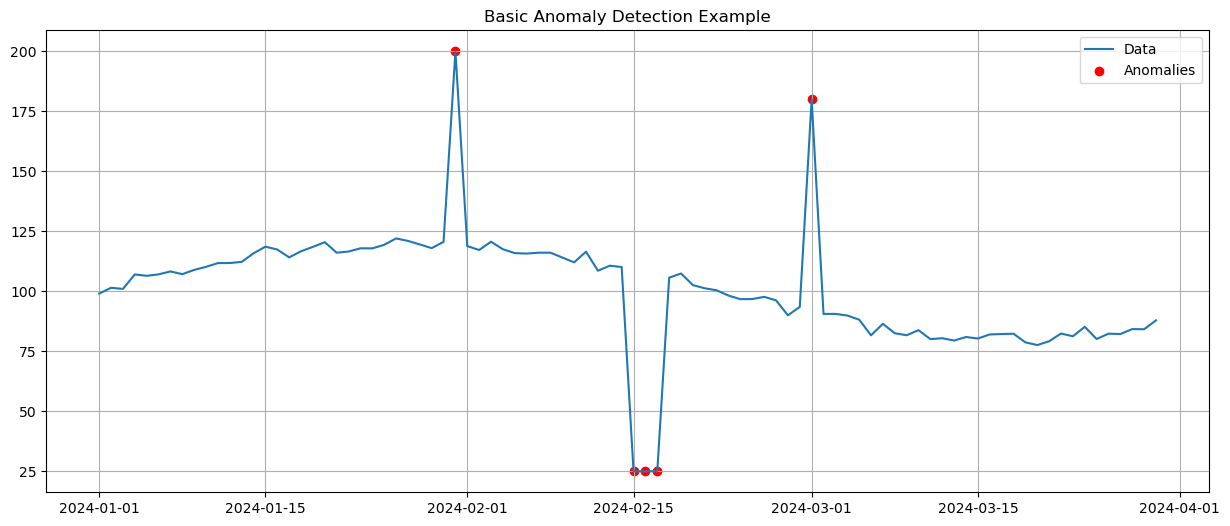


Detected Anomalies:
Date: 2024-01-31, Value: 200.00, Confidence: 98.42%
Date: 2024-02-15, Value: 25.00, Confidence: 96.40%
Date: 2024-02-16, Value: 25.00, Confidence: 97.46%
Date: 2024-02-17, Value: 25.00, Confidence: 96.46%
Date: 2024-03-01, Value: 180.00, Confidence: 96.33%


C:\Users\paulinkenbrandt\AppData\Local\Temp\1\ipykernel_4320\1831670720.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f"Value: {data[idx]:.2f}, "


In [2]:

# Generate sample daily data with known anomalies
dates = pd.date_range('2024-01-01', periods=90, freq='D')

# Create base pattern with weekly seasonality
t = np.linspace(0, 12 * np.pi, 90)
base = 100 + 20 * np.sin(t / 7) + np.random.normal(0, 2, 90)

# Add some obvious anomalies
base[30] = 200  # Single spike
base[45:48] = 25  # Multiple consecutive low values
base[60] = 180  # Another spike

data = pd.Series(base, index=dates, name='Daily Values')

# Initialize and configure detector
config = SHESDConfig(
    max_anomalies=0.2,  # Allow up to 10% of points to be anomalies
    alpha=0.05,         # 95% confidence level
    hybrid=True,        # Use robust statistics
    seasonal_period=7   # Weekly seasonality
)
detector = TwitterSHESD(config)

# Detect anomalies
result = detector.fit_predict(data)

# Extract anomalies and plot
anomalies = pd.Series(
    [score.is_anomaly for score in result.scores],
    index=data.index
)

plt.figure(figsize=(15, 6))
plt.plot(data.index, data, label='Data')
plt.scatter(data[anomalies].index, data[anomalies], 
           color='red', marker='o', label='Anomalies')
plt.title('Basic Anomaly Detection Example')
plt.legend()
plt.grid(True)
plt.show()

# Print details about detected anomalies
print("\nDetected Anomalies:")
for idx, score in enumerate(result.scores):
    if score.is_anomaly:
        print(f"Date: {data.index[idx].date()}, "
              f"Value: {data[idx]:.2f}, "
              f"Confidence: {score.confidence:.2%}")


## Example 2: Hourly Server Metrics

### Overview
This example focuses on analyzing hourly server metrics with daily seasonality patterns and weekend effects. It's particularly useful for:
- Server monitoring
- Infrastructure metrics
- Application performance monitoring
- Resource utilization tracking

### Key Features
- Hourly data processing
- Daily seasonality detection
- Weekend pattern recognition
- Multiplicative decomposition for level-dependent patterns
- Detailed anomaly scoring

### Configuration
```python
config = SHESDConfig(
    max_anomalies=0.05,    # More conservative threshold
    seasonal_period=24,     # Daily seasonality
    decomposition_method='multiplicative',  # Pattern varies with level
    auto_detect_period=False  # Known period
)
```

### Visualization
Produces two plots:
1. Main time series plot:
   - Original CPU usage data
   - Highlighted anomalies
2. Anomaly score plot:
   - Continuous anomaly scores
   - Detection threshold

### Analysis Output
Provides detailed anomaly analysis including:
- Total number of anomalies
- Timestamp of each anomaly
- Actual value at anomaly point
- Anomaly score and confidence
- Contributing factors to each anomaly

### Use Cases
- IT infrastructure monitoring
- Cloud resource optimization
- Capacity planning
- Service level monitoring
- Performance troubleshooting



C:\Users\paulinkenbrandt\AppData\Local\Temp\1\ipykernel_4320\3386624116.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range('2024-01-01', periods=168, freq='H')  # One week


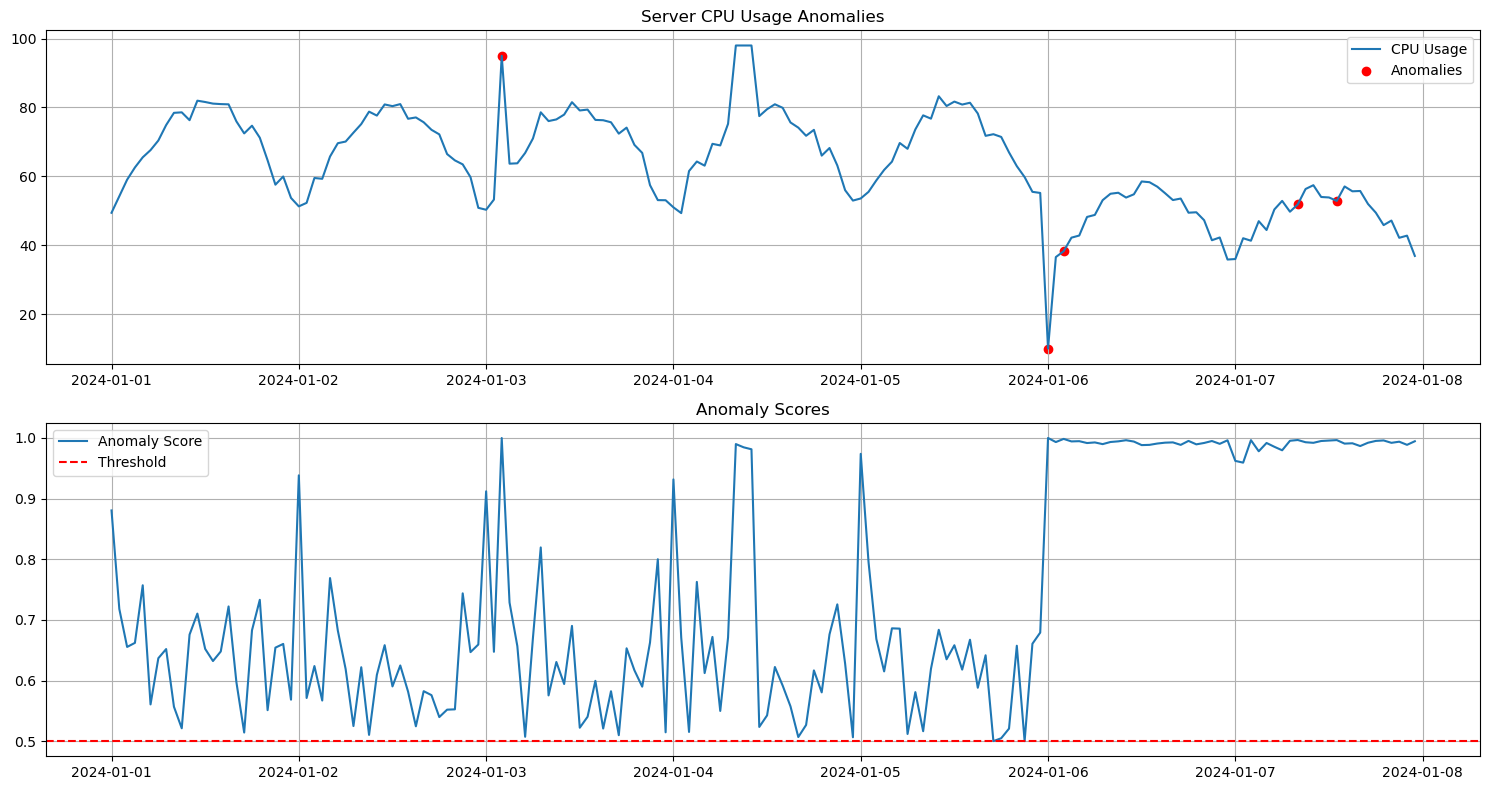


Anomaly Analysis:
Total anomalies detected: 5

Details of detected anomalies:

Timestamp: 2024-01-03 02:00:00
CPU Usage: 95.0%
Anomaly Score: 1.000
Confidence: 99.98%
Contributing Factors:
  - deviation: 9.485
  - relative_score: 1.000

Timestamp: 2024-01-06 00:00:00
CPU Usage: 10.0%
Anomaly Score: 1.000
Confidence: 100.00%
Contributing Factors:
  - deviation: 13.378
  - relative_score: 1.000

Timestamp: 2024-01-06 02:00:00
CPU Usage: 38.3%
Anomaly Score: 0.998
Confidence: 99.70%
Contributing Factors:
  - deviation: 6.498
  - relative_score: 0.998

Timestamp: 2024-01-07 08:00:00
CPU Usage: 51.9%
Anomaly Score: 0.997
Confidence: 99.34%
Contributing Factors:
  - deviation: 5.704
  - relative_score: 0.997

Timestamp: 2024-01-07 13:00:00
CPU Usage: 52.9%
Anomaly Score: 0.997
Confidence: 99.31%
Contributing Factors:
  - deviation: 5.660
  - relative_score: 0.997


In [3]:

"""Example with hourly server metrics."""
# Generate sample hourly server metrics
dates = pd.date_range('2024-01-01', periods=168, freq='H')  # One week

# Create daily pattern with some noise
hour_of_day = np.array([i.hour for i in dates])
day_of_week = np.array([i.dayofweek for i in dates])

# Base load pattern (higher during work hours)
base_load = 50 + 30 * np.sin(np.pi * hour_of_day / 24)
# Weekend effect (lower load)
weekend_effect = np.where(day_of_week >= 5, 0.7, 1.0)
# Add some random variation
noise = np.random.normal(0, 2, 168)

cpu_usage = base_load * weekend_effect + noise

# Add some anomalies
# Spike during off-hours
cpu_usage[50] = 95
# Sustained high usage
cpu_usage[80:83] = 98
# Unusual drop
cpu_usage[120] = 10

data = pd.Series(cpu_usage, index=dates, name='CPU Usage (%)')

# Configure detector for hourly data
config = SHESDConfig(
    max_anomalies=0.025,    # More conservative threshold
    seasonal_period=24,     # Daily seasonality
    decomposition_method='multiplicative',  # Pattern varies with level
    auto_detect_period=False  # We know the period
)
detector = TwitterSHESD(config)

# Detect anomalies
result = detector.fit_predict(data)

# Plot results with confidence scores
plt.figure(figsize=(15, 8))
plt.subplot(2, 1, 1)
plt.plot(data.index, data, label='CPU Usage')
anomalies = [score.is_anomaly for score in result.scores]
plt.scatter(data[anomalies].index, data[anomalies],
            color='red', marker='o', label='Anomalies')
plt.title('Server CPU Usage Anomalies')
plt.legend()
plt.grid(True)

# Plot anomaly scores
plt.subplot(2, 1, 2)
scores = [score.score for score in result.scores]
plt.plot(data.index, scores, label='Anomaly Score')
plt.axhline(y=0.5, color='r', linestyle='--', label='Threshold')
plt.title('Anomaly Scores')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Analyze results
print("\nAnomaly Analysis:")
print(f"Total anomalies detected: {sum(anomalies)}")
print("\nDetails of detected anomalies:")
for i, score in enumerate(result.scores):
    if score.is_anomaly:
        print(f"\nTimestamp: {dates[i]}")
        print(f"CPU Usage: {cpu_usage[i]:.1f}%")
        print(f"Anomaly Score: {score.score:.3f}")
        print(f"Confidence: {score.confidence:.2%}")
        print("Contributing Factors:")
        for factor, value in score.contributing_features.items():
            print(f"  - {factor}: {value:.3f}")


## Example 3: Real-time Monitoring

### Overview
This example showcases real-time anomaly detection with streaming data. It's designed for continuous monitoring scenarios where immediate detection is required.

### Key Features
- Streaming data processing
- Real-time anomaly detection
- Sliding window analysis
- Immediate alerting
- Continuous visualization

### Technical Requirements
- Minimum 48 data points required for initial analysis
- Uses sliding window of 168 points (one week of hourly data)
- Handles both daily and weekly patterns

### Configuration
```python
config = SHESDConfig(
    max_anomalies=0.02,     # Expect 2% anomalies
    seasonal_period=24,      # Daily seasonality
    hybrid=True,            # Use robust statistics
    decomposition_method='additive'
)
```

### Implementation Details
The example includes:
1. Data Stream Simulation:
   - Base value with daily pattern
   - Weekly seasonality
   - Random noise
   - Occasional anomalies (2% probability)

2. Processing Window:
   - Minimum 48 points for baseline
   - Maximum 168 points (1 week) retention
   - Continuous updates

3. Error Handling:
   - Graceful handling of insufficient data
   - Exception management for processing errors
   - Continuous operation despite errors

### Output and Visualization
- Real-time anomaly alerts with:
  - Timestamp
  - Anomalous value
  - Confidence score
  - Contributing features
- Final visualization showing:
  - Complete time series
  - Marked anomalies
  - Summary statistics

### Use Cases
- Network monitoring
- IoT sensor data analysis
- System health monitoring
- Transaction fraud detection
- Real-time security monitoring
- Process control systems

## Best Practices and Tips

### General Usage
1. **Configuration Selection**:
   - Start with conservative `max_anomalies` (0.01-0.05)
   - Use `hybrid=True` for robustness against extreme values
   - Set `seasonal_period` based on known patterns

2. **Data Preparation**:
   - Ensure consistent time intervals
   - Handle missing values before analysis
   - Consider data normalization for better results

3. **Performance Optimization**:
   - Adjust window sizes based on memory constraints
   - Balance detection delay vs accuracy
   - Consider downsampling for high-frequency data

### Troubleshooting
Common issues and solutions:
- **Insufficient Data**: Ensure at least 2 complete cycles (48 points for daily patterns)
- **Too Many Anomalies**: Adjust `max_anomalies` and `alpha` parameters
- **False Positives**: Increase `alpha` for more conservative detection
- **Missed Anomalies**: Decrease `alpha` or adjust seasonal period

### Extension Points
The examples can be extended by:
- Adding custom preprocessing steps
- Implementing different alerting mechanisms
- Customizing visualization options
- Adding domain-specific feature extraction
- Implementing persistence for historical analysis

Starting real-time monitoring simulation...
Processed 48 points...

Anomaly detected at 2024-12-01 17:06:06.235796:
Value: 73.01
Confidence: 99.04%
Contributing features:
  - deviation: 5.339
  - relative_score: 0.998

Anomaly detected at 2024-12-01 23:06:06.256797:
Value: 39.68
Confidence: 99.93%
Contributing features:
  - deviation: 7.996
  - relative_score: 1.000
Processed 72 points...

Anomaly detected at 2024-12-02 17:06:06.324828:
Value: 167.05
Confidence: 99.91%
Contributing features:
  - deviation: 7.656
  - relative_score: 1.000
Processed 96 points...
Processed 120 points...
Processed 144 points...
Processed 168 points...

Anomaly detected at 2024-12-07 03:06:06.765828:
Value: 36.76
Confidence: 97.14%
Contributing features:
  - deviation: 4.232
  - relative_score: 0.988
Processed 192 points...

Anomaly detected at 2024-12-08 07:06:06.904802:
Value: 152.22
Confidence: 98.74%
Contributing features:
  - deviation: 5.060
  - relative_score: 0.998
Processed 216 points...
Processed 

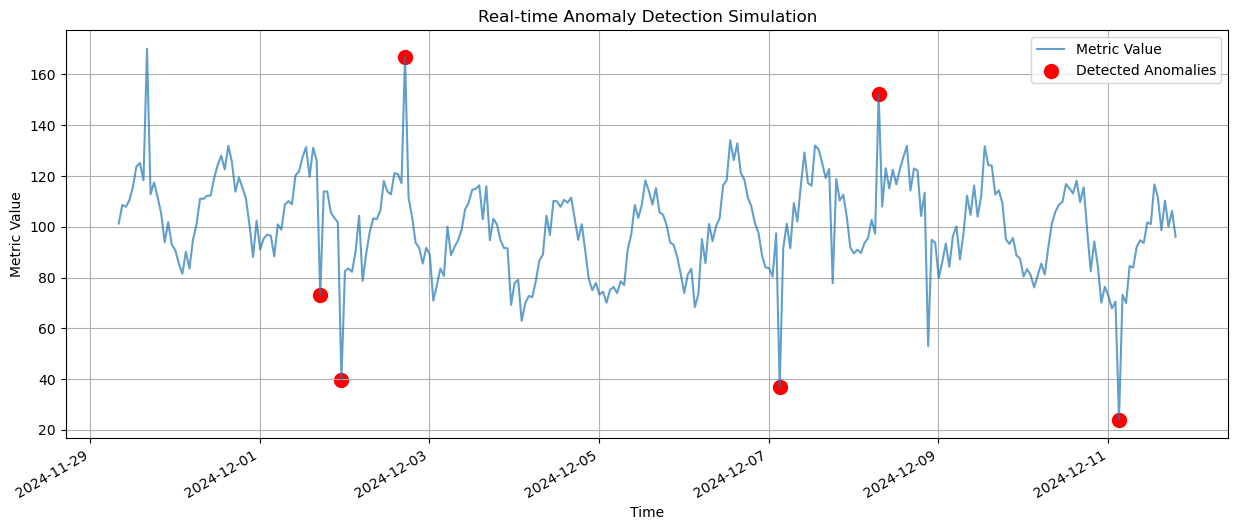


Monitoring Summary:
Total points processed: 300
Total anomalies detected: 6

Anomalies detected at:
  2024-12-01 17:06:06: 73.01
  2024-12-01 23:06:06: 39.68
  2024-12-02 17:06:06: 167.05
  2024-12-07 03:06:06: 36.76
  2024-12-08 07:06:06: 152.22
  2024-12-11 03:06:07: 24.00


In [4]:

"""Example of using the detector for real-time monitoring."""

def simulate_metric_stream(n_points=1000):
    """Simulate a stream of metric data."""
    base = 100
    for i in range(n_points):
        # Add daily pattern
        hour = i % 24
        daily_pattern = 20 * np.sin(2 * np.pi * hour / 24)
        
        # Add weekly pattern
        day = i % 168  # 168 = 24 * 7 hours in a week
        weekly_pattern = 10 * np.sin(2 * np.pi * day / 168)
        
        # Add noise
        noise = np.random.normal(0, 5)
        
        # Occasionally add anomalies
        if np.random.random() < 0.02:  # 2% chance of anomaly
            anomaly = np.random.choice([-50, 50])
        else:
            anomaly = 0
        
        yield base + daily_pattern + weekly_pattern + noise + anomaly

# Configure detector
config = SHESDConfig(
    max_anomalies=0.02,     # Expect 2% anomalies
    seasonal_period=24,      # Daily seasonality
    hybrid=True,            # Use robust statistics
    decomposition_method='additive'  # Use additive decomposition
)
detector = TwitterSHESD(config)

# Initialize storage for online monitoring
min_points = 48  # Minimum points needed for seasonal decomposition
window_size = 168  # Keep 1 week of hourly data
data_buffer = []
dates = []
anomalies = []

print("Starting real-time monitoring simulation...")
print(f"Collecting initial {min_points} points for baseline...")

# Process stream
for i, value in enumerate(simulate_metric_stream(300)):
    current_time = datetime.now() + timedelta(hours=i)
    data_buffer.append(value)
    dates.append(current_time)
    
    # Wait until we have enough data
    if len(data_buffer) >= min_points:
        try:
            # Create series from recent data
            # Use either the full window size or all available data, whichever is smaller
            buffer_size = min(len(data_buffer), window_size)
            recent_data = pd.Series(
                data_buffer[-buffer_size:],
                index=dates[-buffer_size:]
            )
            
            # Detect anomalies
            result = detector.fit_predict(recent_data)
            
            # Check if the latest point is anomalous
            latest_score = result.scores[-1]
            if latest_score.is_anomaly:
                print(f"\nAnomaly detected at {current_time}:")
                print(f"Value: {value:.2f}")
                print(f"Confidence: {latest_score.confidence:.2%}")
                print("Contributing features:")
                for feature, importance in latest_score.contributing_features.items():
                    print(f"  - {feature}: {importance:.3f}")
                anomalies.append((current_time, value))
                
        except Exception as e:
            print(f"Warning: Error processing data point at {current_time}: {str(e)}")
            continue
        
        # Optional: Print status every 24 points
        if len(data_buffer) % 24 == 0:
            print(f"Processed {len(data_buffer)} points...")

# Plot final results
plt.figure(figsize=(15, 6))
plt.plot(dates, data_buffer, label='Metric Value', alpha=0.7)

if anomalies:
    anomaly_dates, anomaly_values = zip(*anomalies)
    plt.scatter(anomaly_dates, anomaly_values, 
               color='red', marker='o', s=100, label='Detected Anomalies')

plt.title('Real-time Anomaly Detection Simulation')
plt.xlabel('Time')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)

# Format x-axis to show dates nicely
plt.gcf().autofmt_xdate()

plt.show()

# Print summary statistics
print("\nMonitoring Summary:")
print(f"Total points processed: {len(data_buffer)}")
print(f"Total anomalies detected: {len(anomalies)}")
if anomalies:
    print("\nAnomalies detected at:")
    for date, value in anomalies:
        print(f"  {date.strftime('%Y-%m-%d %H:%M:%S')}: {value:.2f}")

